In [166]:
import pandas as pd
import matplotlib.pyplot as plt
drivers = pd.read_csv('data/cleaned_drivers.csv')
results = pd.read_csv('data/cleaned_results.csv')
races = pd.read_csv('data/cleaned_races.csv')
constructors = pd.read_csv('data/cleaned_constructors.csv')
pit_stops = pd.read_csv('data/cleaned_pit_stops.csv')
status = pd.read_csv('data/cleaned_status.csv')

In [ ]:
pit_stops['duration_sec'] = pit_stops['milliseconds'] / 1000
avg_pit = pit_stops.groupby(['raceId','driverId'])['duration_sec'].mean().reset_index()
pit_analysis = pd.merge(results, avg_pit, on = ['raceId', 'driverId'])
pit_analysis['position'] = pd.to_numeric(pit_analysis['position'], errors = 'coerce')
pit_clean = pit_analysis[(pit_analysis['position'].notna()) & (pit_analysis['duration_sec'] < 60)]
correlation = pit_clean['duration_sec'].corr(pit_clean['position'])

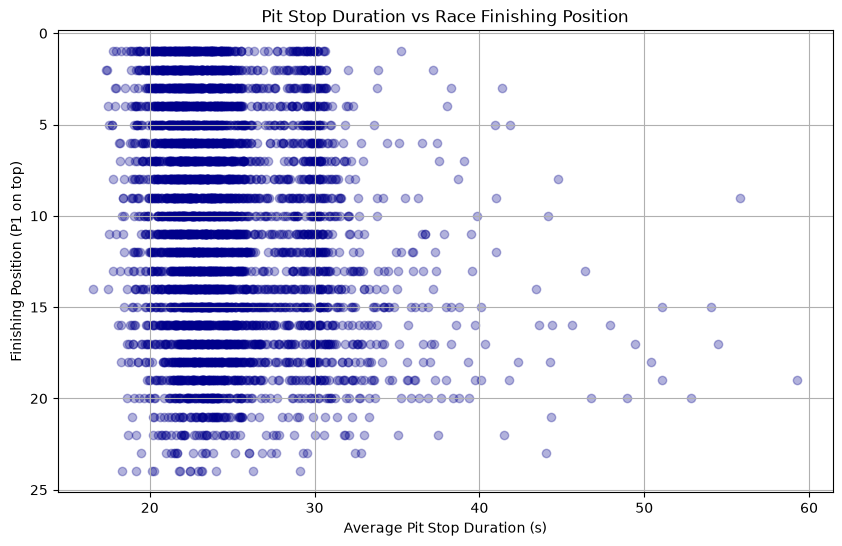

In [168]:
plt.figure(figsize=(10,6))
plt.scatter(pit_clean['duration_sec'], pit_clean['position'], color = 'darkblue', alpha = 0.3)
plt.title('Pit Stop Duration vs Race Finishing Position')
plt.xlabel('Average Pit Stop Duration (s)')
plt.ylabel('Finishing Position (P1 on top)')
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

1. Pit Stop Duration vs Race Finishing Position
Correlation Coefficient: '0.1681' (Weak positive correlation).
Key Finding: Pit stop duration has a minimal linear impact on the final race outcome. While severe pit errors (>30s) drop drivers down the order, marginal differences in pit stop speed (e.g., 2.2s vs 2.8s) do not dictate race winners.
Business Takeaway: Raw pace, tire degradation management, and on-track strategy play a far more dominant role in overall performance than purely pit lane stationary time.

In [169]:
team_pits = pit_hybrid.groupby('constructor_name')['duration_sec'].median().reset_index()
team_pits = team_pits.sort_values(by='duration_sec', ascending =  True)


In [170]:
m1 = pd.merge(pit_stops, results, on = ['raceId', 'driverId'])
m2 = pd.merge(m1, constructors, on = ['constructorId'])
m3 = pd.merge(m2, races, on = ['raceId'])
pit_hybrid = m3[(m3['year'] >= 2014) & (m3['duration_sec']<50)]

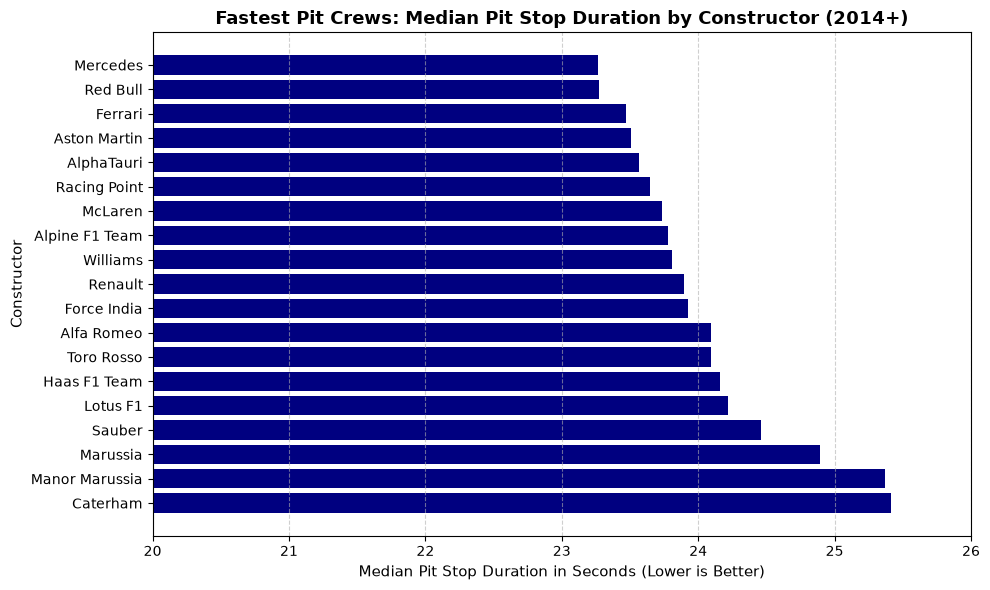

In [171]:
plt.figure(figsize=(10,6))
plt.barh(team_pits['constructor_name'], team_pits['duration_sec'], color = 'navy')
plt.xlim(20, 26)
plt.title('Fastest Pit Crews: Median Pit Stop Duration by Constructor (2014+)', fontsize=13, fontweight='bold')
plt.xlabel('Median Pit Stop Duration in Seconds (Lower is Better)', fontsize=11)
plt.ylabel('Constructor', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. Constructor Pit Crew Efficiency in the Hybrid Era (2014+)
Top Performers: Mercedes (23.26s) and Red Bull Racing (23.28s) hold the most consistent pit operations, separated by mere hundredths of a second.
Why Median Matters: Using the median filters out mechanical failures, traffic delays in the fast lane, and penalty-serving stops, revealing true crew execution capability.
Insight: Consistency at the top level highlights the engineering precision and training investment made by championship contenders.

In [172]:
res_races = pd.merge(results, races, on='raceId')
pole_sitters = res_races[(res_races['year'] >= 2014) & (res_races['grid_position'] == 1)]
pole_sitters['position'] = pd.to_numeric(pole_sitters['position'], errors='coerce')
pole_sitters['won'] = (pole_sitters['position'] == 1)
rate = pole_sitters['won'].mean()
print(rate)

0.5257731958762887


In [173]:
circuit_names = {
    70: 'Red Bull Ring',
    1: 'Melbourne',
    3: 'Bahrain',
    4: 'Barcelona',
    6: 'Monaco',
    9: 'Silverstone',
    11: 'Hungaroring',
    13: 'Spa-Francorchamps',
    14: 'Monza',
    24: 'Abu Dhabi',
    71: 'Sochi'
}

pole_sitters['circuit_name'] = pole_sitters['circuitId'].map(circuit_names)
named_poles = pole_sitters.dropna(subset=['circuit_name'])
circuit_stats = named_poles.groupby('circuit_name')['won'].agg(
    conversion_rate = 'mean', 
    total_races = 'count'
).reset_index()
circuit_stats['conversion_rate'] = circuit_stats['conversion_rate'] * 100
circuit_stats = circuit_stats.sort_values(by = 'conversion_rate', ascending = False)

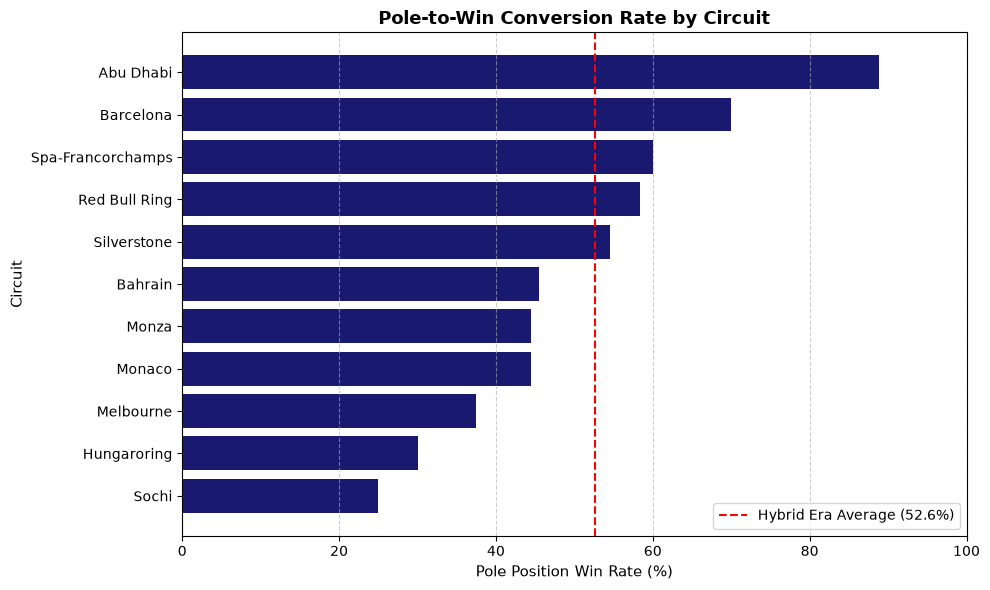

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(circuit_stats['circuit_name'], circuit_stats['conversion_rate'], color = 'midnightblue')
plt.xlim(0, 100)
plt.axvline(x=rate * 100, color='red', linestyle='--', linewidth=1.5, label=f'Hybrid Era Average ({rate*100:.1f}%)')
plt.title('Pole-to-Win Conversion Rate by Circuit', fontsize=13, fontweight='bold')
plt.xlabel('Pole Position Win Rate (%)', fontsize=11)
plt.ylabel('Circuit', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

3. Key Insights: Pole-to-Win Conversion Rate (Hybrid Era 2014+)

Baseline Efficiency: Across the Hybrid Era, securing Pole Position yields an overall win probability of 52.58%. Starting from P1 offers a clear advantage, yet nearly half of all race wins are decided by race pace, tyre management, and pit stop execution.
Track-Dominant Circuits: Abu Dhabi (88.89%) and Barcelona (70.00%) exhibit the highest conversion rates. Track layouts with limited overtaking zones and stable weather make qualifying performance the single most critical factor for Sunday's victory.
Strategic & Environmental Vulnerability: Monaco (44.44%) and Hungaroring (30.00%) fall well below the era's average. Despite being notoriously narrow circuits, high probabilities of Safety Cars, undercut/overcut pit strategies, and unpredictable weather frequently shuffle the running order.
Slipstream Disadvantage into Turn 1: Sochi (25.00%)records the lowest conversion rate in the dataset. The long drag from the starting grid to Turn 1 heavily benefits P2 and P3 due to the aerodynamic tow (slipstream), frequently compromising the pole-sitter before the first braking zone.

In [175]:
results_with_year = pd.merge(results, races, on = 'raceId', how = 'inner')
hybrid_results = results_with_year[results_with_year['year'] >= 2014]
hybrid_results = pd.merge(hybrid_results, status, on = 'statusId', how = 'left')

In [176]:
def is_mech(text):
    non_mech_statuses = ['Disqualified', 'Accident', 'Collision', 'Collision damage', 'Spun off']
    text = str(text)
    if 'Finished' in text or 'Lap' in text or text in non_mech_statuses:
        return 0
    else:
        return 1
hybrid_results['is_mech_dnf'] = hybrid_results['status'].apply(is_mech)

In [177]:
team_reliability = hybrid_results.groupby('constructorId').agg({
    'is_mech_dnf' : 'mean',
    'points' : 'sum'
}).reset_index()


In [178]:
team_reliability = team_reliability.merge(constructors[['constructorId', 'constructor_name']], on = 'constructorId', how = 'left')
team_reliability['is_mech_pct'] = (team_reliability['is_mech_dnf'] * 100).round(1)
team_reliability= team_reliability.sort_values(by = 'is_mech_pct', ascending = False)

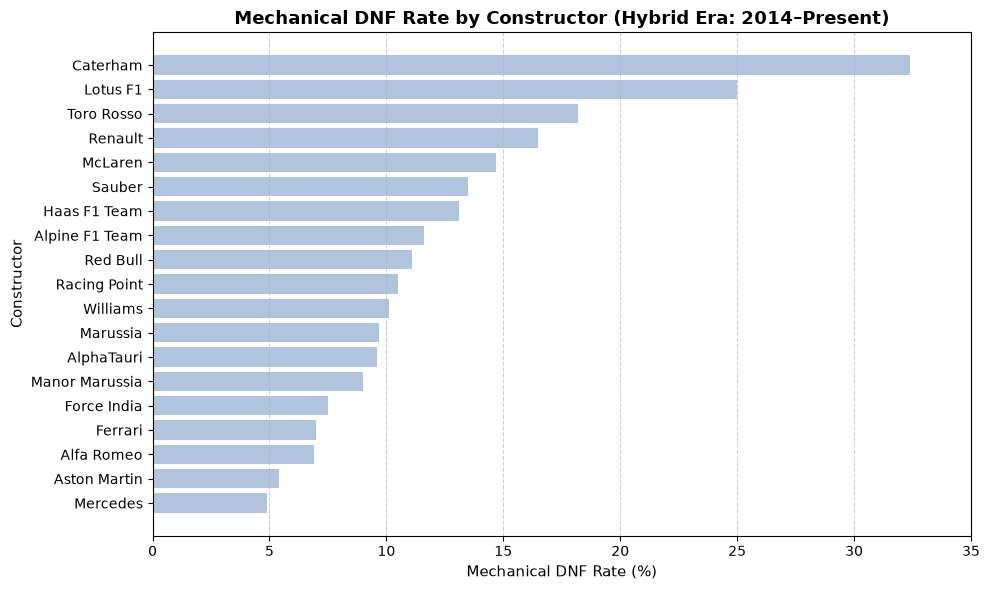

In [182]:
plt.figure(figsize=(10,6))
plt.barh(team_reliability['constructor_name'], team_reliability['is_mech_pct'], color = 'lightsteelblue')
plt.xlim(0, 35)
plt.title('Mechanical DNF Rate by Constructor (Hybrid Era: 2014–Present)', fontsize=13, fontweight='bold')
plt.xlabel('Mechanical DNF Rate (%)', fontsize=11)
plt.ylabel('Constructor', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

4. Mechanical DNF Rate vs Constructor Performance (Hybrid Era)
Key Findings:
Mechanical reliability serves as a prerequisite for championship contention rather than a sole differentiator. Mercedes achieved the lowest mechanical failure rate on the grid at 4.9%, translating technical durability into 6,139.5 championship points. In contrast, backmarkers like Caterham (32.4% DNF) and Lotus F1 (25.0% DNF) suffered terminal issues in up to one-third of their starts, severely restricting point scoring opportunities.

Engineering & Strategic Takeaway:
Power unit resilience creates a high performance floor. While midfield teams like McLaren (14.7% DNF) and Renault (16.5% DNF) possessed top ten race pace, recurring technical retirements caused massive point deficits during their customer engine transitions. Superior reliability enabled frontrunning teams to maximize points even on weekends with sub-optimal pure car speed.